# 06 Resilience Performance

Analyzes resilience, availability, adaptation time, detection rate, and latency from the attached data.

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT=Path.cwd().parent if Path.cwd().name=="notebooks" else Path.cwd()
sys.path.insert(0,str(ROOT/"src"))
from dds_analysis import *
DATA=ROOT/"data"; OUT=ROOT/"outputs"; OUT.mkdir(exist_ok=True)
df=load_seqacs(DATA); validate_schema(df)
print(f"Loaded {len(df):,} rows and {len(df.columns)} columns")


Loaded 520,000 rows and 37 columns


In [2]:
perf=df.groupby("scenario").agg(resilience=("resilience_score","mean"),availability=("availability_score","mean"),
adaptation_s=("adaptation_time_sec","mean"),latency_ms=("latency_ms","mean"),
attack_detection=("attack_detected","mean"))
perf.to_csv(OUT/"performance_by_scenario.csv"); display(perf)
print("Detection rate among attacked records:",detection_rate(df))

,resilience,availability,adaptation_s,latency_ms,attack_detection
scenario,,,,,
S1_Normal,0.795755,0.950377,0.806786,31.983853,0.060564
S2_Quantum_Eavesdropping,0.757381,0.930669,1.299912,35.986734,0.961999
S3_Harvest_Now_Decrypt_Later,0.780662,0.945168,1.498843,34.022761,0.924837
S4_QKD_Link_Failure,0.742941,0.925170,1.100813,34.041397,0.948171
S5_PQC_Computational_Overload,0.757346,0.936143,1.701963,40.957541,0.912393
S6_Hybrid_Adversarial_Attack,0.726762,0.926232,1.998111,46.991674,0.905230


Detection rate among attacked records: 0.9305630664734258


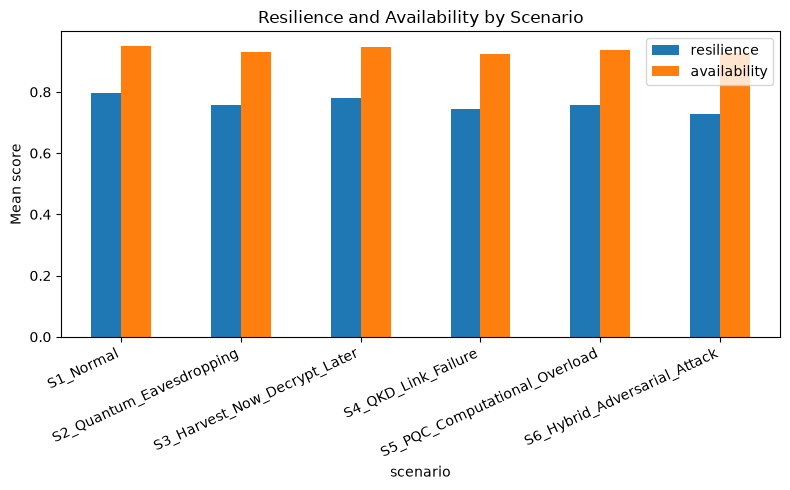

In [3]:
plt.figure(figsize=(8,5)); perf[["resilience","availability"]].plot(kind="bar",ax=plt.gca())
plt.ylabel("Mean score"); plt.title("Resilience and Availability by Scenario")
plt.xticks(rotation=25,ha="right"); plt.tight_layout(); plt.savefig(OUT/"fig_resilience_availability.png",dpi=300); plt.show()